In [198]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
import struct
from array import array
from os.path  import join
import time
import networkx as nx
from IPython.display import display, clear_output

np.set_printoptions(threshold=np.inf)
rng = np.random.default_rng(seed=42)

In [199]:
TIME_RESOLUTION = 0.01

THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
CURVATURE = 1

IMAGE_THRESHOLD = 90

# BETA = 0.56
# TAU = 2.6 #ms
# K = 700 #nA

BETA = 0.76
TAU = 9
K = 766

FLUSH_TIME = 200
FINAL_COLS = 10

NEURON_COUNT = 300
TRAIN_BATCH_SIZE = 6000
TEST_BATCH_SIZE = 1000

In [200]:
def IGT_exponent(v, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    return np.exp(-(np.maximum(0,(np.absolute(v) - threshold_voltage)) / scale_voltage) ** curvature)

def evolve_IGT(k, v, In_1, beta, tau):
    one_vector = np.ones_like(In_1)
    current_in_infinity = (k * (one_vector - IGT_exponent(v)))

    return current_in_infinity + (In_1 - current_in_infinity) * np.exp(-(TIME_RESOLUTION / tau) ** beta)

def current_to_voltage(current_in_infinity, k, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    return np.power(np.log(1/np.maximum(1e-9,(1-(current_in_infinity/k)))), 1/curvature) * scale_voltage + threshold_voltage

In [201]:
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

In [202]:
def image_to_pulses(img, threshold=IMAGE_THRESHOLD):
    pulse_train = img.flatten()

    pulse_train = (pulse_train > threshold).astype(np.uint8)
    # pulse_train = (pulse_train / 255 * SCALE_VOLTAGE).astype(np.float16)

    # zeros = np.zeros(2 * len(pulse_train), dtype=np.uint8)
    # zeros[::2] = pulse_train
    # pulse_train = zeros

    pulse_train = pulse_train.reshape((28, 28)).T

    return pulse_train

In [203]:
input_path = 'MNIST'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)

(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

In [204]:
def get_images_batch(batch_size = 600, x=x_train, y=y_train):
    random_idx = rng.choice(len(x), size=batch_size, replace=False)

    x_batch = x[random_idx]
    y_batch = np.eye(10)[y[random_idx]]

    return x_batch, y_batch

In [205]:
zeros_flush = np.zeros((28, 1))

time_space = np.linspace(0, zeros_flush.shape[0]* TIME_RESOLUTION, zeros_flush.shape[0])

In [206]:
# Input weights
weight_input = rng.normal(0, 1, size=(NEURON_COUNT, 28))

# Neurons' states
current_state = np.zeros((NEURON_COUNT, 1))

# Intern weights
weight_reservoir = rng.normal(0, 1, size=(NEURON_COUNT, NEURON_COUNT))

# Readout weights
weight_output = rng.normal(0, 1, size=(10, NEURON_COUNT))

sum_matrix = np.ones_like(current_state) @ (np.ones_like(current_state).T @ abs(weight_reservoir))
sum_matrix = (lambda x: 1/x)(sum_matrix)
normalized_reservoir = sum_matrix*weight_reservoir

true_results = []
states = []


In [207]:
def run_reservoir(
        images,
        labels,
        normalized_reservoir,
        reservoir_state,
        weight_input,
        weight_output,
        bias_output = np.array([]),
        mode = "TRAIN",
        image_threshold=IMAGE_THRESHOLD,
        neuron_count=NEURON_COUNT
    ):

    # G = nx.from_numpy_array(np.abs(weight_reservoir), create_using=nx.DiGraph)
    # pos = nx.spring_layout(G, seed=42)

    # fig, ax = plt.subplots(figsize=(6, 6))

    states = []
    predicted_results = []

    confusion_matrix = np.zeros((labels.shape[1], labels.shape[1]))
    correct_predictions_count = 0

    current_state = reservoir_state.copy()

    for i, k in enumerate(images):
        image = image_to_pulses(k, image_threshold) * 1.8

        for data in image:
            data = data.reshape(28, 1)

            result_current = normalized_reservoir @ current_state

            current_state = evolve_IGT(
                K, 
                current_to_voltage(result_current, K) + (weight_input @ data), 
                current_state, 
                BETA, 
                TAU
            )

            # ax.clear()
            # node_colors = current_state.flatten()
            # nx.draw(
            #     G, pos, ax=ax,
            #     node_color=node_colors, cmap=plt.cm.viridis,
            #     with_labels=False, node_size=200, arrows=False
            # )
            # clear_output(wait=True)
            # display(fig)
        
        for _ in range(FINAL_COLS):
            result_current = normalized_reservoir @ current_state

            current_state = evolve_IGT(
                K, 
                current_to_voltage(result_current, K) + (weight_input @ zeros_flush), 
                current_state, 
                BETA, 
                TAU
            )

        # print(f"add {current_state.flatten()} nos {states}")
        states.append(current_state.flatten())
        predicted_results.append(labels[i])
        
        if mode == "TEST":
            y = (weight_output @ current_state) + bias_output.reshape(-1, 1)

            predicted_label = np.argmax(y)
            expected_label = np.argmax(labels[i])

            confusion_matrix[expected_label][predicted_label] += 1

            correct_predictions_count += (expected_label == predicted_label)

        # for _ in range(FLUSH_TIME):
        #     result_current = normalized_reservoir @ current_state

        #     current_state = evolve_IGT(
        #         K, 
        #         current_to_voltage(result_current, K) + (weight_input @ zeros_flush), 
        #         current_state, 
        #         BETA, 
        #         TAU
        #     )
        
        # print(np.average(current_state))

        current_state = np.zeros((neuron_count, 1))

    states = np.array(states)
    predicted_results = np.array(predicted_results)

    if mode == "TRAIN":
        ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
        ridge.fit(states, predicted_results)

        weight_output = ridge.coef_
        bias_output = ridge.intercept_

        return weight_output, bias_output, current_state
    
    if mode == "TEST":
        confusion_matrix = confusion_matrix / confusion_matrix.sum(axis=1, keepdims=True)

        return correct_predictions_count, confusion_matrix

In [208]:
images, labels = get_images_batch(TRAIN_BATCH_SIZE)

time_to_train = time.time()

weight_output, bias_output, In = run_reservoir(images, labels, normalized_reservoir, current_state, weight_input, weight_output)

time_to_train = time.time() - time_to_train

-------------------------
VARIABLES:

Beta = 0.76
Tau = 9
K = 766

Neuron count = 300

Flush time = 200

Train batch size = 6000
Test batch size = 1000

Image threshold = 90

Time to train = 12.70s

-------------------------
ACCURACY:

824 / 1000 : 82.40 %


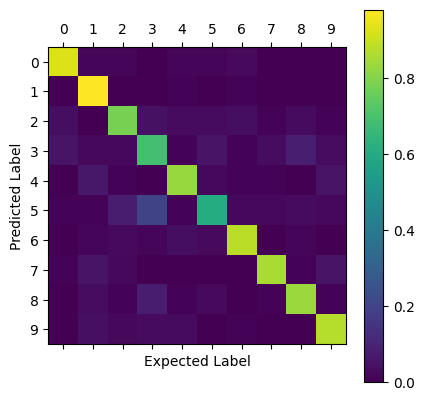

In [209]:
images_test, labels_test = get_images_batch(TEST_BATCH_SIZE, x_test, y_test)

correct_predictions_count, confusion_matrix = run_reservoir(images_test, labels_test, normalized_reservoir, In, weight_input, weight_output, bias_output, mode="TEST")

print(f"""-------------------------
VARIABLES:
      
Beta = {BETA}
Tau = {TAU}
K = {K}

Neuron count = {NEURON_COUNT}

Flush time = {FLUSH_TIME}

Train batch size = {TRAIN_BATCH_SIZE}
Test batch size = {TEST_BATCH_SIZE}

Image threshold = {IMAGE_THRESHOLD}

Time to train = {time_to_train:.2f}s

-------------------------
ACCURACY:
""")
print(f"{correct_predictions_count} / {len(labels_test)} : {100*(correct_predictions_count/len(labels_test)):.2f} %")

plt.matshow(confusion_matrix)
plt.colorbar()
plt.xlabel("Expected Label")
plt.ylabel("Predicted Label")
plt.xticks(np.arange(confusion_matrix.shape[0]))
plt.yticks(np.arange(confusion_matrix.shape[1]))
plt.show()

In [210]:
# neuron_count = range(1, 602, 20)
# acc_results = []
# time_results = []

# for n in neuron_count:
#     print(f"Treino para {n} neurônios")

#     # Input weights
#     weight_input = rng.normal(0, 1, size=(n, 28))

#     # Neurons' states
#     current_state = np.zeros((n, 1))

#     # Intern weights
#     weight_reservoir = rng.normal(0, 1, size=(n, n))

#     # Readout weights
#     weight_output = rng.normal(0, 1, size=(10, n))

#     sum_matrix = np.ones_like(current_state) @ (np.ones_like(current_state).T @ abs(weight_reservoir))
#     sum_matrix = (lambda x: 1/x)(sum_matrix)
#     normalized_reservoir = sum_matrix*weight_reservoir

#     true_results = []
#     states = []

#     time_to_train = time.time()

#     weight_output, bias_output, current_state = run_reservoir(images, labels, normalized_reservoir, current_state, weight_input, weight_output, neuron_count=n)
#     time_to_train = time.time() - time_to_train

#     correct_predictions_count, confusion_matrix = run_reservoir(images_test, labels_test, normalized_reservoir, current_state, weight_input, weight_output, bias_output, mode="TEST", neuron_count=n)

#     acc_results.append(correct_predictions_count / len(labels_test))
#     time_results.append(time_to_train)

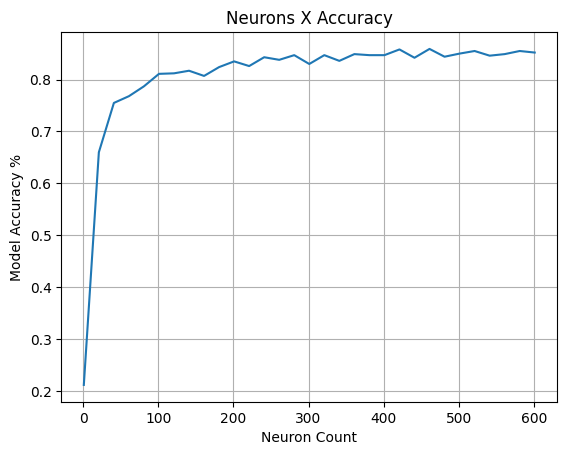

In [211]:
plt.plot(neuron_count, acc_results)
plt.title("Neurons X Accuracy")
plt.xlabel("Neuron Count")
plt.ylabel("Model Accuracy %")
plt.grid()
plt.show()

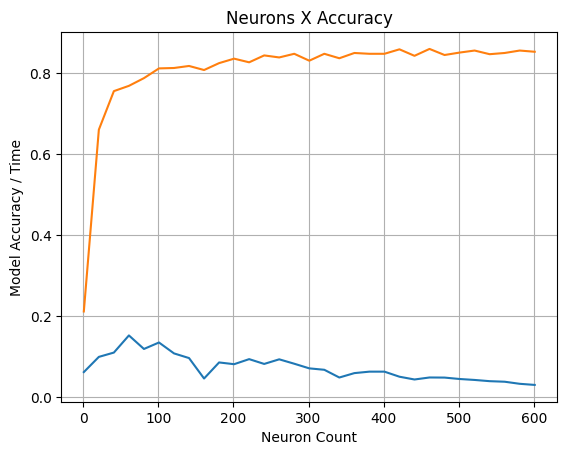

In [212]:
plt.plot(neuron_count, np.sqrt(np.array(acc_results)) / np.array(time_results))
plt.plot(neuron_count, np.array(acc_results))
plt.title("Neurons X Accuracy")
plt.xlabel("Neuron Count")
plt.ylabel("Model Accuracy / Time")
plt.grid()
plt.show()